importing libraries

In [ ]:
import numpy as np
import pandas as pd

loading datasets

In [ ]:
fact = pd.read_csv("/content/fact_air_health.csv")
dim=pd.read_csv("/content/dim_location.csv")

columns in both the tables

In [ ]:
print(fact.columns)
print(dim.columns)

Index(['fact_id', 'date', 'location_id', 'aqi_value', 'aqi_category', 'pm25',
       'pm10', 'no2', 'so2', 'co', 'o3', 'temperature_c', 'humidity_pct',
       'wind_speed_kmph', 'ed_visits_respiratory',
       'hospital_admissions_respiratory', 'outpatient_visits_respiratory',
       'mortality_count_respiratory', 'prescriptions_issued',
       'exceedance_flag', 'Unnamed: 20', 'Unnamed: 21'],
      dtype='object')
Index(['location_id', 'city', 'state', 'region', 'population',
       'population_density', 'baseline_aqi'],
      dtype='object')


In [ ]:
print("dim.shape",dim.shape)
print("fact.shape",fact.shape)

dim.shape (4, 7)
fact.shape (4384, 22)


using merge method combining the both tables with the common column

In [ ]:
merged_df = pd.merge(fact, dim, on="location_id", how="left")

no.of rows aand columns in the merged table

In [ ]:
merged_df.shape

(4384, 28)

total duplicated rows

In [ ]:

merged_df.duplicated().sum()

np.int64(0)

no duplicate rows

columns in the merged table

In [ ]:
merged_df.columns

Index(['fact_id', 'date', 'location_id', 'aqi_value', 'aqi_category', 'pm25',
       'pm10', 'no2', 'so2', 'co', 'o3', 'temperature_c', 'humidity_pct',
       'wind_speed_kmph', 'ed_visits_respiratory',
       'hospital_admissions_respiratory', 'outpatient_visits_respiratory',
       'mortality_count_respiratory', 'prescriptions_issued',
       'exceedance_flag', 'Unnamed: 20', 'Unnamed: 21', 'city', 'state',
       'region', 'population', 'population_density', 'baseline_aqi'],
      dtype='object')

 count of missing values in each column

In [ ]:
print(merged_df.isna().sum()) #null values nan not a number

fact_id                               0
date                                  0
location_id                           0
aqi_value                             0
aqi_category                          0
pm25                                142
pm10                                  0
no2                                   0
so2                                   0
co                                    0
o3                                    0
temperature_c                         0
humidity_pct                        177
wind_speed_kmph                     133
ed_visits_respiratory                 0
hospital_admissions_respiratory       0
outpatient_visits_respiratory         0
mortality_count_respiratory         220
prescriptions_issued                 90
exceedance_flag                       0
Unnamed: 20                        4384
Unnamed: 21                        4383
city                                  0
state                                 0
region                                0


deleting unnecessary columns

In [ ]:
merged_df = merged_df.drop(columns=["Unnamed: 20", "Unnamed: 21"])

handling missing values forward filling

In [ ]:
merged_df['pm25'] = merged_df['pm25'].fillna(merged_df['pm25'].median())
merged_df['humidity_pct'] = merged_df['humidity_pct'].fillna(merged_df['humidity_pct'].mean())
merged_df['wind_speed_kmph'] = merged_df['wind_speed_kmph'].fillna(method='ffill')
merged_df['mortality_count_respiratory'] = merged_df['mortality_count_respiratory'].fillna(0)
merged_df['prescriptions_issued'] = merged_df['prescriptions_issued'].fillna(0)

/tmp/ipykernel_2577/3320330494.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df['wind_speed_kmph'] = merged_df['wind_speed_kmph'].fillna(method='ffill')


rechecking the null values

In [ ]:
print(merged_df.isna().sum()) #null values nan not a number

fact_id                            0
date                               0
location_id                        0
aqi_value                          0
aqi_category                       0
pm25                               0
pm10                               0
no2                                0
so2                                0
co                                 0
o3                                 0
temperature_c                      0
humidity_pct                       0
wind_speed_kmph                    0
ed_visits_respiratory              0
hospital_admissions_respiratory    0
outpatient_visits_respiratory      0
mortality_count_respiratory        0
prescriptions_issued               0
exceedance_flag                    0
city                               0
state                              0
region                             0
population                         0
population_density                 0
baseline_aqi                       0
dtype: int64


In [ ]:
merged_df.shape

(4384, 26)

In [ ]:
merged_df.head()

,fact_id,date,location_id,aqi_value,aqi_category,pm25,pm10,no2,so2,co,...,outpatient_visits_respiratory,mortality_count_respiratory,prescriptions_issued,exceedance_flag,city,state,region,population,population_density,baseline_aqi
0,3561,30/09/2023,4,75.1,Moderate,49.50,93.5,20.2,2.8,1.52,...,90,1.0,133.0,0,Hyderabad,Telangana,South,10500000,18480,120
1,573,26/07/2024,1,91.3,Moderate,59.50,100.5,25.8,8.4,1.22,...,268,2.0,422.0,0,Delhi,Delhi,North,32900000,11320,210
2,3569,08/10/2023,4,101.0,Unhealthy for Sensitive Groups,70.25,95.1,14.8,6.9,1.50,...,85,1.0,132.0,0,Hyderabad,Telangana,South,10500000,18480,120
3,1355,16/09/2023,2,89.5,Moderate,57.40,95.6,24.9,9.3,2.03,...,171,1.0,276.0,0,Mumbai,Maharashtra,West,20700000,20700,140
4,1147,20/02/2023,2,174.1,Unhealthy,102.30,155.7,36.9,13.0,2.81,...,307,3.0,489.0,1,Mumbai,Maharashtra,West,20700000,20700,140


removing spaces

In [ ]:
for col in merged_df.select_dtypes(include=['object']).columns:
    merged_df[col] = merged_df[col].astype(str).str.strip()

In [ ]:
for col in merged_df.select_dtypes(include=['object']).columns:
  print(col,merged_df[col].unique())

date ['30/09/2023' '26/07/2024' '08/10/2023' ... '18/10/2023' '31/07/2025'
 '10/12/2023']
aqi_category ['Moderate' 'Unhealthy for Sensitive Groups' 'Unhealthy'
 'unhealthy for sensitive groups' 'Good' 'Hazardous' 'moderate'
 'UNHEALTHY' 'Very Unhealthy' 'Unhealthy For Sensitive Groups' 'good'
 'MODERATE' 'unhealthy' 'hazardous' 'very unhealthy' 'HAZARDOUS'
 'Very unhealthy' 'GOOD']
city ['Hyderabad' 'Delhi' 'Mumbai' 'Bengaluru']
state ['Telangana' 'Delhi' 'Maharashtra' 'Karnataka']
region ['South' 'North' 'West']


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   fact_id                          4384 non-null   int64  
 1   date                             4384 non-null   object 
 2   location_id                      4384 non-null   int64  
 3   aqi_value                        4384 non-null   float64
 4   aqi_category                     4384 non-null   object 
 5   pm25                             4384 non-null   float64
 6   pm10                             4384 non-null   float64
 7   no2                              4384 non-null   float64
 8   so2                              4384 non-null   float64
 9   co                               4384 non-null   float64
 10  o3                               4384 non-null   float64
 11  temperature_c                    4384 non-null   float64
 12  humidity_pct        

converting the datatype of date into date type

In [ ]:
merged_df['date'] = pd.to_datetime(merged_df['date'])

/tmp/ipykernel_2577/755652490.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  merged_df['date'] = pd.to_datetime(merged_df['date'])


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   fact_id                          4384 non-null   int64         
 1   date                             4384 non-null   datetime64[ns]
 2   location_id                      4384 non-null   int64         
 3   aqi_value                        4384 non-null   float64       
 4   aqi_category                     4384 non-null   object        
 5   pm25                             4384 non-null   float64       
 6   pm10                             4384 non-null   float64       
 7   no2                              4384 non-null   float64       
 8   so2                              4384 non-null   float64       
 9   co                               4384 non-null   float64       
 10  o3                               4384 non-null   float64    

In [ ]:
import warnings
warnings.filterwarnings("ignore")

converting object data type into category for storage management

In [ ]:
for i in merged_df.columns:
  if merged_df[i].dtype == "object":
    merged_df[i] = merged_df[i].astype('category')

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   fact_id                          4384 non-null   int64         
 1   date                             4384 non-null   datetime64[ns]
 2   location_id                      4384 non-null   int64         
 3   aqi_value                        4384 non-null   float64       
 4   aqi_category                     4384 non-null   category      
 5   pm25                             4384 non-null   float64       
 6   pm10                             4384 non-null   float64       
 7   no2                              4384 non-null   float64       
 8   so2                              4384 non-null   float64       
 9   co                               4384 non-null   float64       
 10  o3                               4384 non-null   float64    

checking unique values

In [ ]:
for col in merged_df.select_dtypes(include=['category']).columns:
  print(col,merged_df[col].unique())

aqi_category ['Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'unhealthy for sensitive groups', 'Good', ..., 'hazardous', 'very unhealthy', 'HAZARDOUS', 'Very unhealthy', 'GOOD']
Length: 18
Categories (18, object): ['GOOD', 'Good', 'HAZARDOUS', 'Hazardous', ..., 'moderate', 'unhealthy',
                          'unhealthy for sensitive groups', 'very unhealthy']
city ['Hyderabad', 'Delhi', 'Mumbai', 'Bengaluru']
Categories (4, object): ['Bengaluru', 'Delhi', 'Hyderabad', 'Mumbai']
state ['Telangana', 'Delhi', 'Maharashtra', 'Karnataka']
Categories (4, object): ['Delhi', 'Karnataka', 'Maharashtra', 'Telangana']
region ['South', 'North', 'West']
Categories (3, object): ['North', 'South', 'West']


converting into lower case

In [ ]:
for col in merged_df.select_dtypes(include=['category']).columns:
    # Step 1: Convert to string
    merged_df[col] = merged_df[col].astype(str).str.lower()

    # Step 2: Rebuild as categorical with new lowercase categories
    merged_df[col] = pd.Categorical(merged_df[col])

In [ ]:
for col in merged_df.select_dtypes(include=['category']).columns:
  print(col,merged_df[col].unique())

aqi_category ['moderate', 'unhealthy for sensitive groups', 'unhealthy', 'good', 'hazardous', 'very unhealthy']
Categories (6, object): ['good', 'hazardous', 'moderate', 'unhealthy',
                         'unhealthy for sensitive groups', 'very unhealthy']
city ['hyderabad', 'delhi', 'mumbai', 'bengaluru']
Categories (4, object): ['bengaluru', 'delhi', 'hyderabad', 'mumbai']
state ['telangana', 'delhi', 'maharashtra', 'karnataka']
Categories (4, object): ['delhi', 'karnataka', 'maharashtra', 'telangana']
region ['south', 'north', 'west']
Categories (3, object): ['north', 'south', 'west']


DATA IS CLEANED


In [ ]:
merged_df.head()

,fact_id,date,location_id,aqi_value,aqi_category,pm25,pm10,no2,so2,co,...,outpatient_visits_respiratory,mortality_count_respiratory,prescriptions_issued,exceedance_flag,city,state,region,population,population_density,baseline_aqi
0,3561,2023-09-30,4,75.1,moderate,49.50,93.5,20.2,2.8,1.52,...,90,1.0,133.0,0,hyderabad,telangana,south,10500000,18480,120
1,573,2024-07-26,1,91.3,moderate,59.50,100.5,25.8,8.4,1.22,...,268,2.0,422.0,0,delhi,delhi,north,32900000,11320,210
2,3569,2023-10-08,4,101.0,unhealthy for sensitive groups,70.25,95.1,14.8,6.9,1.50,...,85,1.0,132.0,0,hyderabad,telangana,south,10500000,18480,120
3,1355,2023-09-16,2,89.5,moderate,57.40,95.6,24.9,9.3,2.03,...,171,1.0,276.0,0,mumbai,maharashtra,west,20700000,20700,140
4,1147,2023-02-20,2,174.1,unhealthy,102.30,155.7,36.9,13.0,2.81,...,307,3.0,489.0,1,mumbai,maharashtra,west,20700000,20700,140


In [ ]:
import matplotlib.pyplot as plt

# Creating month for month-wise analysis
merged_df['month'] = merged_df['date'].dt.to_period('M').astype(str)


### 1. What is the average AQI in each city?

city
delhi        200.579288
mumbai       126.249909
hyderabad    106.732938
bengaluru     78.264690
Name: aqi_value, dtype: float64


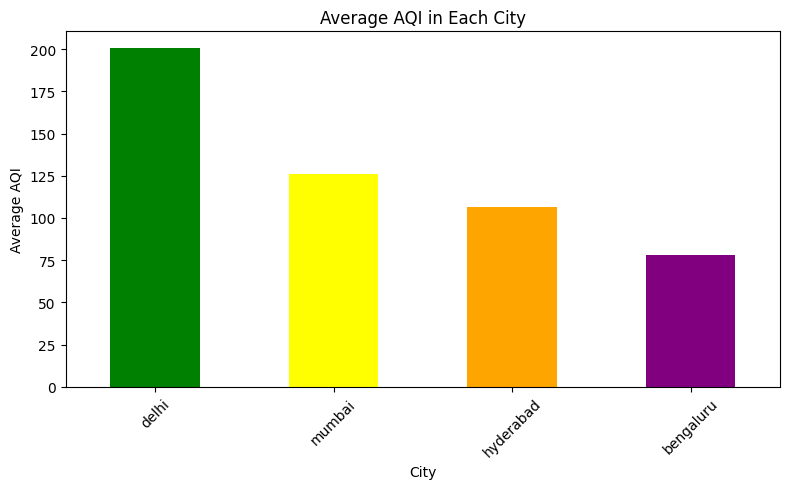

In [76]:
result = merged_df.groupby('city')['aqi_value'].mean().sort_values(ascending=False)
print(result)
color_map = {
    'delhi': 'green',
    'mumbai': 'yellow',
    'hyderabad': 'orange',
    'bengaluru': 'purple',
}
scolors = [color_map[cat] for cat in result.index]
result.plot(kind='bar', figsize=(8,5), color=scolors)
plt.title('Average AQI in Each City')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delhi has the highest average AQI at 200.58, while Bengaluru has the lowest at 78.26.

---


Delhi needs more attention toward air-quality improvement, while Bengaluru can be studied to understand its comparatively lower AQI.

### 2. What is the average AQI in each region?

region
north    200.579288
west     126.249909
south     92.498814
Name: aqi_value, dtype: float64


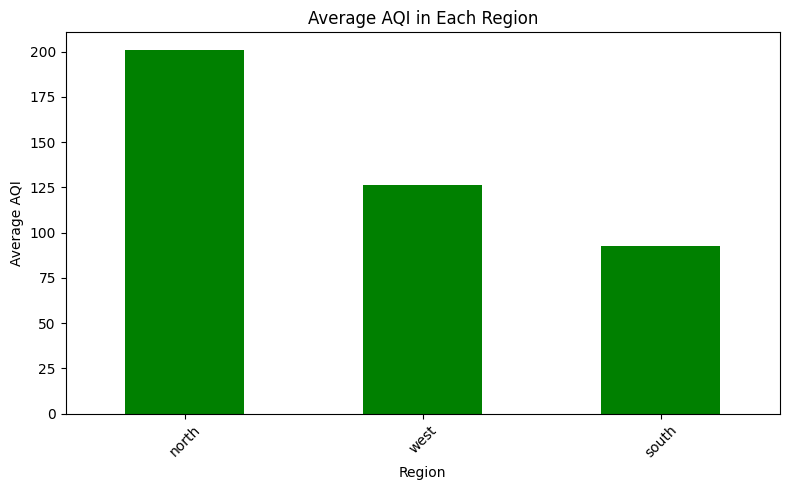

In [ ]:
result = merged_df.groupby('region')['aqi_value'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(8,5),color='green')
plt.title('Average AQI in Each Region')
plt.xlabel('Region')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The North region has the highest average AQI at 200.58, followed by West at 126.25 and South at 92.50.


---
The North region should be given higher priority for pollution monitoring and control.

### 3. Which city has the highest AQI?

city
delhi        200.579288
mumbai       126.249909
hyderabad    106.732938
bengaluru     78.264690
Name: aqi_value, dtype: float64
City with highest AQI: delhi


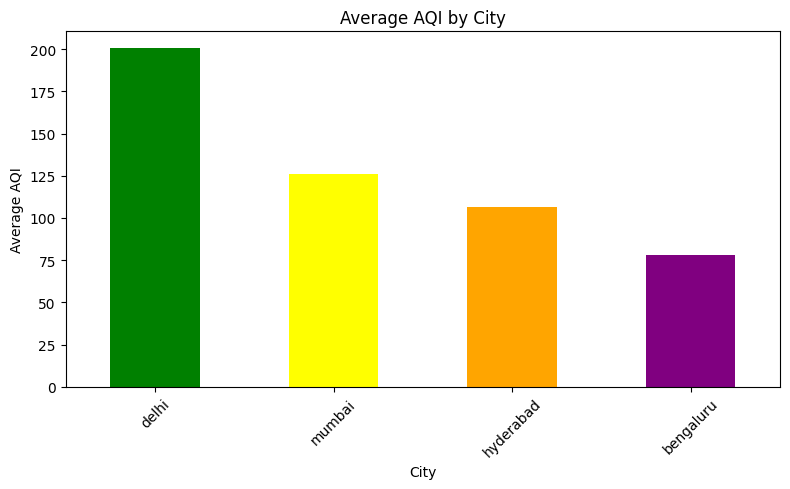

In [77]:
result = merged_df.groupby('city')['aqi_value'].mean().sort_values(ascending=False)
print(result)
print("City with highest AQI:", result.idxmax())

result.plot(kind='bar', figsize=(8,5),color=scolors)
plt.title('Average AQI by City')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delhi has the highest average AQI at 200.58.


---


More pollution-control and air-quality monitoring efforts can be focused on Delhi

### 4. Which city has the lowest AQI?

city
bengaluru     78.264690
hyderabad    106.732938
mumbai       126.249909
delhi        200.579288
Name: aqi_value, dtype: float64
City with lowest AQI: bengaluru


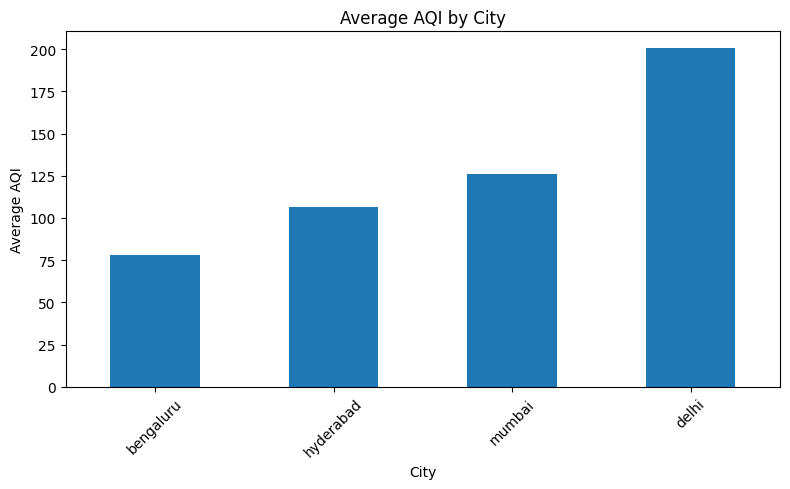

In [81]:
result = merged_df.groupby('city')['aqi_value'].mean().sort_values()
print(result)
print("City with lowest AQI:", result.idxmin())

result.plot(kind='bar', figsize=(8,5))
plt.title('Average AQI by City')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bengaluru has the lowest average AQI at 78.26.


---


Bengaluru's comparatively lower AQI can be used as a reference when comparing air-quality conditions between cities.

### 5. How does AQI change from month to month?

month
2023-01    191.729839
2023-02    185.300000
2023-03    158.165323
2023-04    125.480000
2023-05     91.879032
2023-06     66.515833
2023-07     57.191935
2023-08     66.729839
2023-09     92.187500
2023-10    126.539516
2023-11    161.860833
2023-12    185.691935
2024-01    198.713710
2024-02    184.237069
2024-03    161.550806
2024-04    143.315833
2024-05     92.333871
2024-06     66.752500
2024-07     57.229839
2024-08     69.512097
2024-09     93.851667
2024-10    127.146774
2024-11    164.577500
2024-12    186.645161
2025-01    199.879032
2025-02    188.869643
2025-03    166.258871
2025-04    132.092500
2025-05     94.802419
2025-06     68.310000
2025-07     59.891935
2025-08     68.012097
2025-09     95.797500
2025-10    129.237097
2025-11    166.245000
2025-12    191.869355
Name: aqi_value, dtype: float64


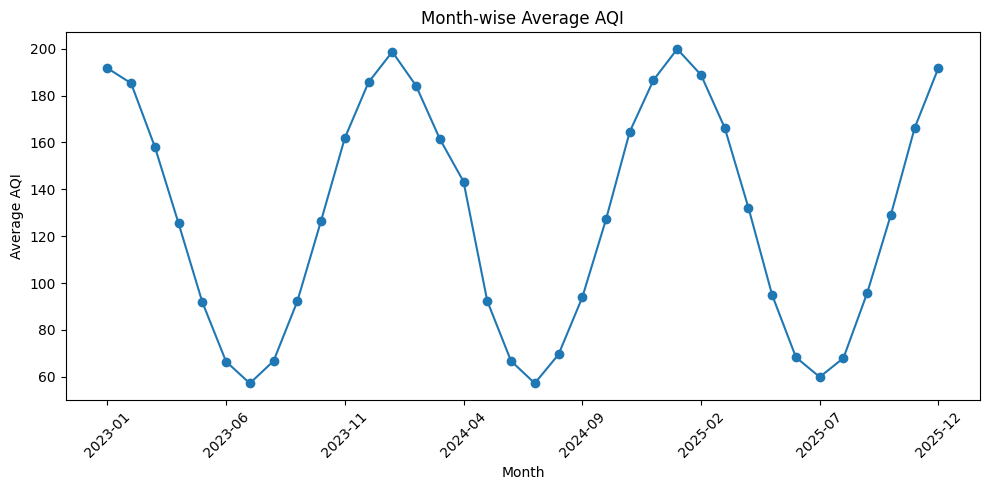

In [ ]:
result = merged_df.groupby('month')['aqi_value'].mean()
print(result)

result.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Month-wise Average AQI')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

AQI is highest around January and generally decreases toward June–July, then increases again toward the end of the year.


---


Resources and public warnings can be increased during months when AQI normally becomes higher.

### 6. Which AQI category is seen the most?

aqi_category
moderate                          1406
unhealthy for sensitive groups    1178
unhealthy                          723
very unhealthy                     489
good                               443
hazardous                          145
Name: count, dtype: int64


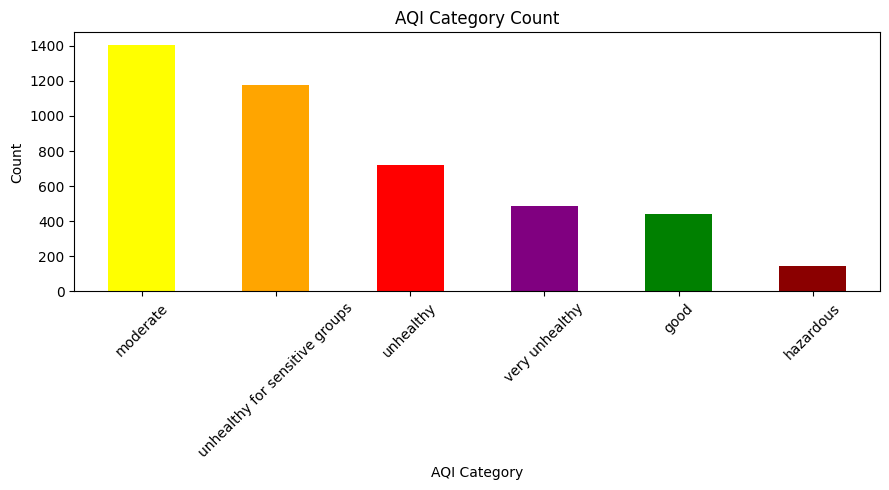

In [67]:
result = merged_df['aqi_category'].value_counts()
print(result)

# Define the color mapping
color_map = {
    'moderate': 'yellow',
    'unhealthy for sensitive groups': 'orange',
    'unhealthy': 'red',
    'very unhealthy': 'purple',
    'good': 'green',
    'hazardous': 'darkred'
}

# Create a list of colors in the order of the categories in 'result'
colors = [color_map[cat] for cat in result.index]

result.plot(kind='bar', figsize=(9,5), color=colors)
plt.title('AQI Category Count')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Moderate category occurs most often with 1,406 records, followed by Unhealthy for Sensitive Groups with 1,178.


---


 Most observations are not in the best air-quality category, so regular monitoring is still important.

### 7. What is the average AQI for each AQI category?

aqi_category
hazardous                         327.341379
very unhealthy                    246.987935
unhealthy                         172.735408
unhealthy for sensitive groups    122.894058
moderate                           75.132575
good                               39.339278
Name: aqi_value, dtype: float64


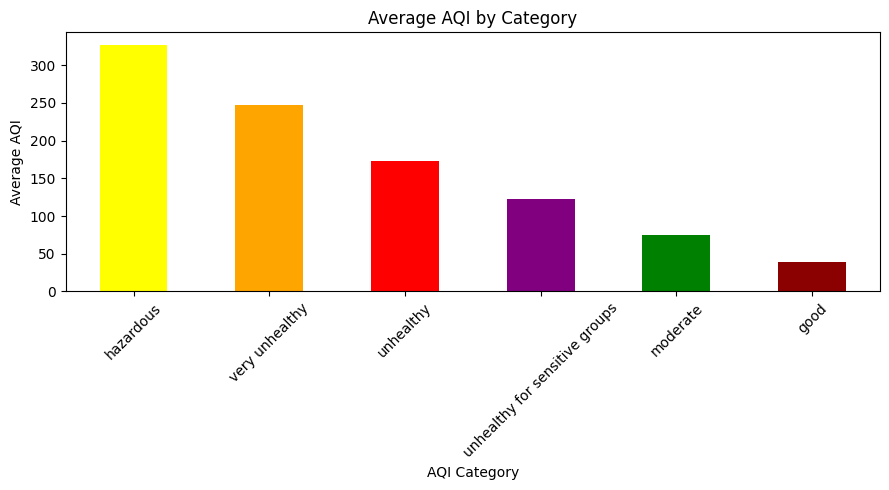

In [68]:
result = merged_df.groupby('aqi_category', observed=True)['aqi_value'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(9,5),color=colors)
plt.title('Average AQI by Category')
plt.xlabel('AQI Category')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average AQI increases from 39.34 for Good to 327.34 for Hazardous.


---


 As air quality moves into worse categories, the level of pollution becomes substantially higher, making the category useful for communicating risk.

### 8. What are the respiratory ED visits in each city?

city
delhi        215.410584
mumbai        91.964416
bengaluru     41.072993
hyderabad     41.037409
Name: ed_visits_respiratory, dtype: float64


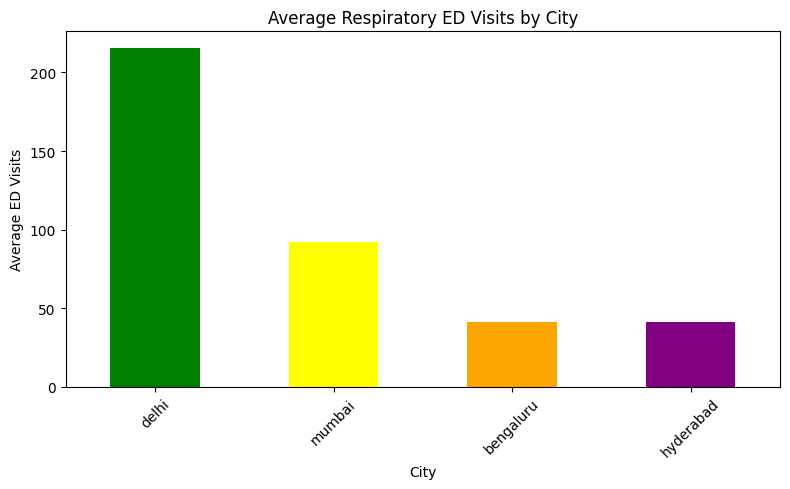

In [80]:
result = merged_df.groupby('city')['ed_visits_respiratory'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(8,5),color=scolors)
plt.title('Average Respiratory ED Visits by City')
plt.xlabel('City')
plt.ylabel('Average ED Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delhi has the highest average respiratory ED visits at 215.41, while Bengaluru and Hyderabad are around 41 visits.


---


Delhi's healthcare system may need more preparation for respiratory emergency cases.

### 9. What are the respiratory hospital admissions in each city?

city
delhi        66.011861
mumbai       27.999088
hyderabad    12.448905
bengaluru    12.386861
Name: hospital_admissions_respiratory, dtype: float64


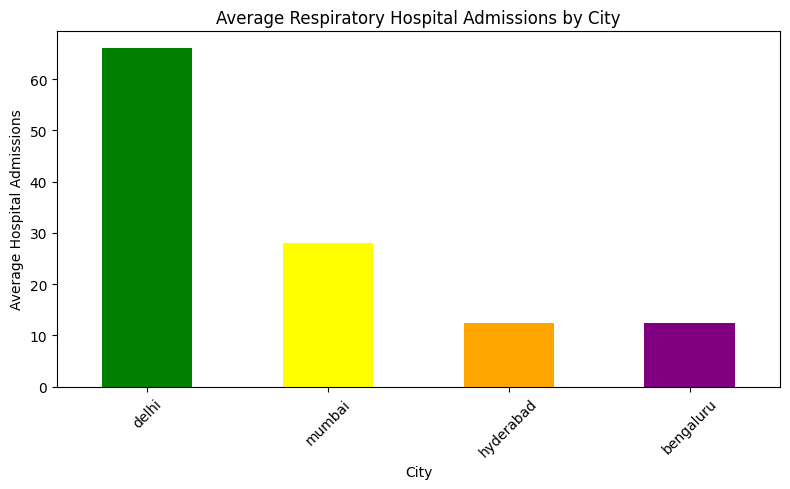

In [82]:
result = merged_df.groupby('city')['hospital_admissions_respiratory'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(8,5),color=scolors)
plt.title('Average Respiratory Hospital Admissions by City')
plt.xlabel('City')
plt.ylabel('Average Hospital Admissions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delhi has the highest average hospital admissions at 66.01, compared with about 12.4 in Bengaluru and Hyderabad.


---


Healthcare resources can be planned more carefully in cities with higher respiratory admissions.

### 10. What are the respiratory outpatient visits in each city?

city
delhi        485.341241
mumbai       208.572993
bengaluru     93.960766
hyderabad     93.317518
Name: outpatient_visits_respiratory, dtype: float64


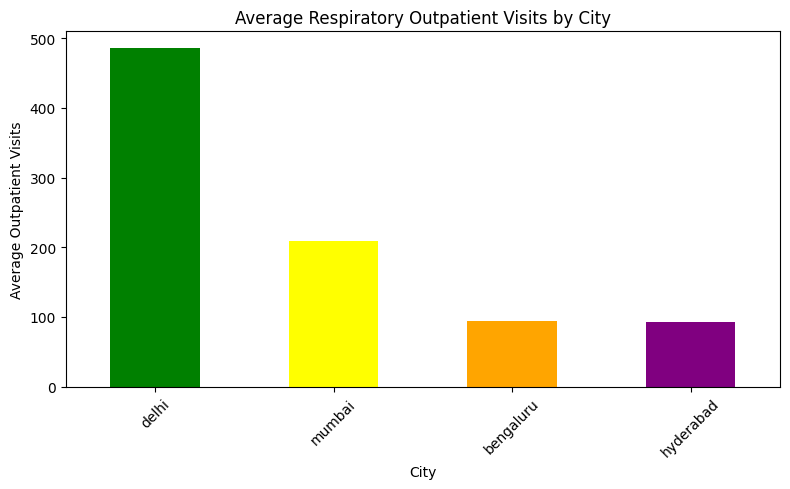

In [85]:
result = merged_df.groupby('city')['outpatient_visits_respiratory'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(8,5),color=scolors)
plt.title('Average Respiratory Outpatient Visits by City')
plt.xlabel('City')
plt.ylabel('Average Outpatient Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delhi has the highest average outpatient visits at 485.34, followed by Mumbai at 208.57.


---


these cities may require greater outpatient capacity for respiratory-related cases.

### 11. How do respiratory ED visits change from month to month?

month
2023-01    135.919355
2023-02    132.678571
2023-03    116.717742
2023-04     96.133333
2023-05     76.419355
2023-06     59.783333
2023-07     52.846774
2023-08     57.435484
2023-09     72.775000
2023-10     93.967742
2023-11    116.941667
2023-12    132.387097
2024-01    140.145161
2024-02    134.370690
2024-03    118.830645
2024-04    105.850000
2024-05     76.451613
2024-06     61.008333
2024-07     53.782258
2024-08     58.790323
2024-09     74.308333
2024-10     95.080645
2024-11    118.225000
2024-12    133.491935
2025-01    143.403226
2025-02    139.464286
2025-03    123.016129
2025-04    102.766667
2025-05     78.822581
2025-06     61.516667
2025-07     55.693548
2025-08     59.758065
2025-09     76.058333
2025-10     97.701613
2025-11    120.800000
2025-12    138.604839
Name: ed_visits_respiratory, dtype: float64


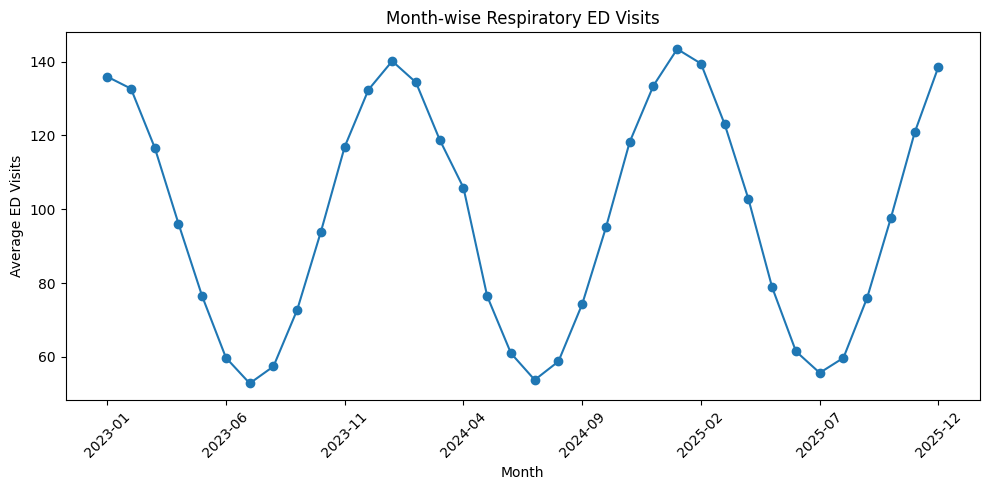

In [ ]:
result = merged_df.groupby('month')['ed_visits_respiratory'].mean()
print(result)

result.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Month-wise Respiratory ED Visits')
plt.xlabel('Month')
plt.ylabel('Average ED Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ED visits are highest around January and lowest around July in the data.


---




 Hospitals can prepare additional emergency resources during months when respiratory visits normally increase.

### 12. How do respiratory hospital admissions change from month to month?

month
2023-01    41.725806
2023-02    40.758929
2023-03    35.645161
2023-04    29.333333
2023-05    23.209677
2023-06    17.925000
2023-07    15.806452
2023-08    17.322581
2023-09    21.983333
2023-10    28.572581
2023-11    35.741667
2023-12    40.653226
2024-01    42.959677
2024-02    41.310345
2024-03    36.395161
2024-04    32.258333
2024-05    23.217742
2024-06    18.358333
2024-07    16.153226
2024-08    17.669355
2024-09    22.575000
2024-10    28.911290
2024-11    36.275000
2024-12    40.991935
2025-01    44.000000
2025-02    42.857143
2025-03    37.750000
2025-04    31.408333
2025-05    23.959677
2025-06    18.550000
2025-07    16.725806
2025-08    18.080645
2025-09    23.233333
2025-10    29.798387
2025-11    37.016667
2025-12    42.548387
Name: hospital_admissions_respiratory, dtype: float64


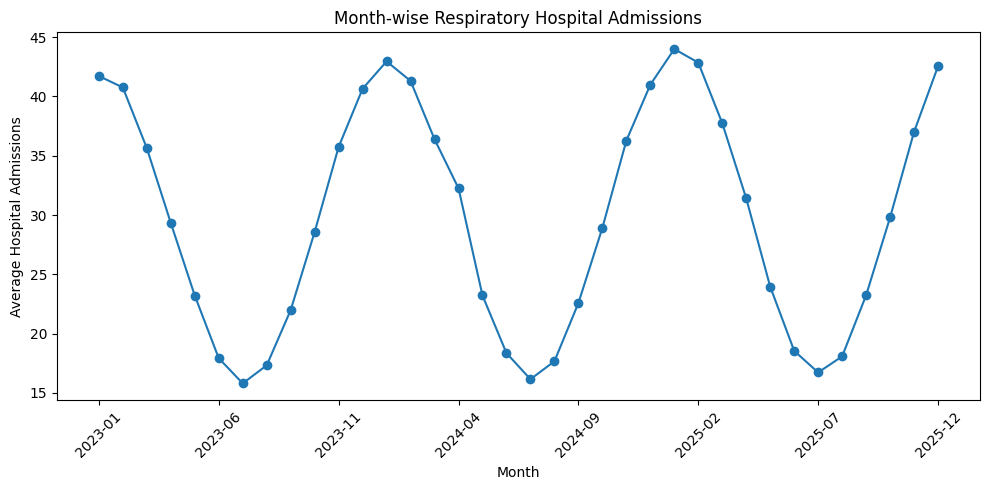

In [ ]:
result = merged_df.groupby('month')['hospital_admissions_respiratory'].mean()
print(result)

result.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Month-wise Respiratory Hospital Admissions')
plt.xlabel('Month')
plt.ylabel('Average Hospital Admissions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hospital admissions follow a similar seasonal pattern, reaching around 44 admissions in January 2025 and falling to around 16–19 during June–August.


---


 Seasonal planning of hospital beds and staff can help handle periods of higher respiratory admissions

### 13. Which city has the most respiratory ED visits on average?

city
delhi        215.410584
mumbai        91.964416
bengaluru     41.072993
hyderabad     41.037409
Name: ed_visits_respiratory, dtype: float64
City with most respiratory ED visits: delhi


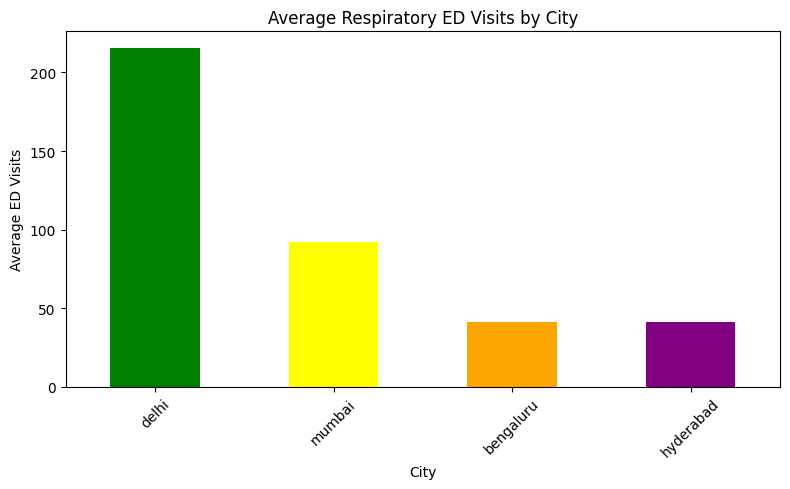

In [86]:
result = merged_df.groupby('city')['ed_visits_respiratory'].mean().sort_values(ascending=False)
print(result)
print("City with most respiratory ED visits:", result.idxmax())

result.plot(kind='bar', figsize=(8,5),color=scolors)
plt.title('Average Respiratory ED Visits by City')
plt.xlabel('City')
plt.ylabel('Average ED Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delhi has the highest average respiratory ED visits at 215.41.


---


 Delhi can be considered a priority area for both respiratory healthcare planning and air-quality improvement.

### 14. Do respiratory ED visits increase when AQI increases?

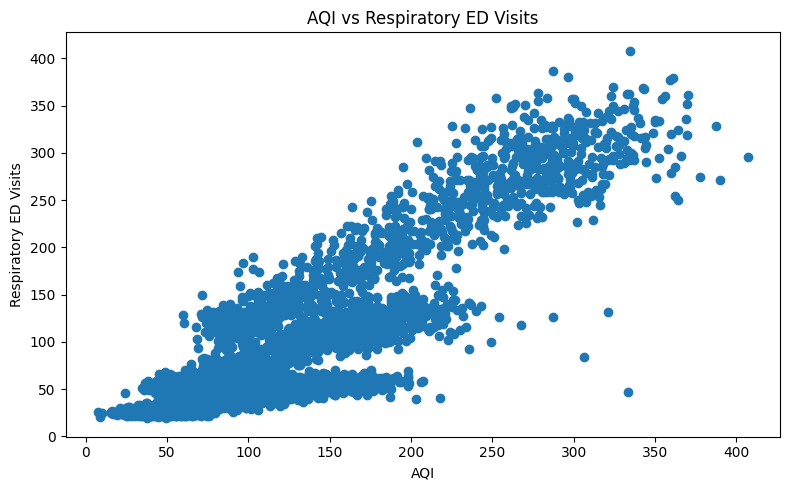

Correlation: 0.8668856948704246


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(merged_df['aqi_value'], merged_df['ed_visits_respiratory'])
plt.title('AQI vs Respiratory ED Visits')
plt.xlabel('AQI')
plt.ylabel('Respiratory ED Visits')
plt.tight_layout()
plt.show()

print("Correlation:", merged_df['aqi_value'].corr(merged_df['ed_visits_respiratory']))

The correlation is 0.867, showing a strong positive relationship in this dataset.


---


When AQI becomes higher, respiratory ED visits also tend to be higher, so healthcare preparedness can be increased during poor-air-quality periods.

### 15. Do hospital admissions increase when AQI increases?

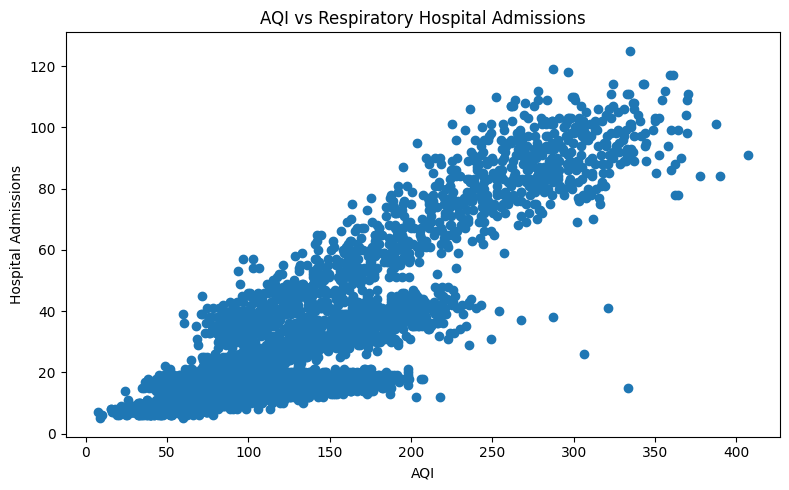

Correlation: 0.8684438087381585


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(merged_df['aqi_value'], merged_df['hospital_admissions_respiratory'])
plt.title('AQI vs Respiratory Hospital Admissions')
plt.xlabel('AQI')
plt.ylabel('Hospital Admissions')
plt.tight_layout()
plt.show()

print("Correlation:", merged_df['aqi_value'].corr(merged_df['hospital_admissions_respiratory']))

The correlation is 0.868, showing a strong positive relationship.


---


Higher AQI periods may require hospitals to be prepared for increased respiratory admissions.

### 16. Do outpatient visits increase when AQI increases?

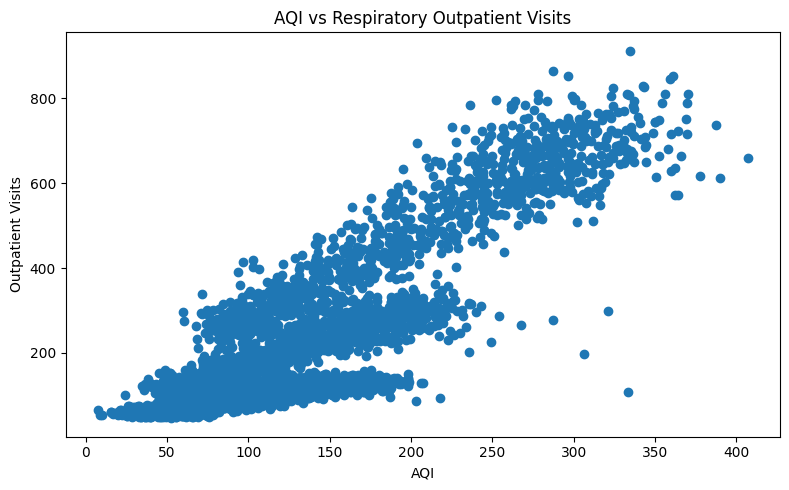

Correlation: 0.8656424967014236


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(merged_df['aqi_value'], merged_df['outpatient_visits_respiratory'])
plt.title('AQI vs Respiratory Outpatient Visits')
plt.xlabel('AQI')
plt.ylabel('Outpatient Visits')
plt.tight_layout()
plt.show()

print("Correlation:", merged_df['aqi_value'].corr(merged_df['outpatient_visits_respiratory']))

The correlation is 0.866, also showing a strong positive relationship.


---


Poorer air-quality periods may increase demand for respiratory outpatient services, so healthcare providers can plan accordingly.

### 17. How are respiratory ED visits different for different AQI categories?

aqi_category
hazardous                         304.765517
very unhealthy                    241.568507
unhealthy                         118.990318
unhealthy for sensitive groups     79.386248
moderate                           51.229018
good                               29.306998
Name: ed_visits_respiratory, dtype: float64


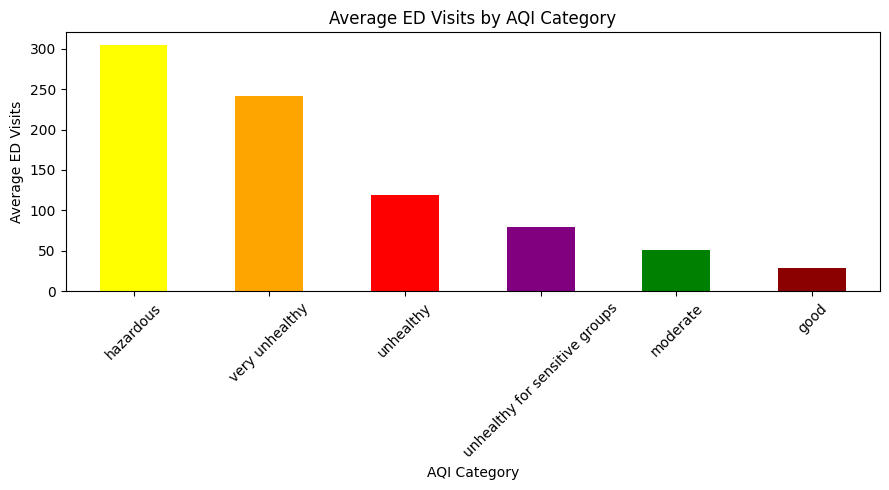

In [88]:
result = merged_df.groupby('aqi_category', observed=True)['ed_visits_respiratory'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(9,5),color=colors)
plt.title('Average ED Visits by AQI Category')
plt.xlabel('AQI Category')
plt.ylabel('Average ED Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average ED visits increase from 29.31 in Good conditions to 304.77 in Hazardous conditions.


---


The large increase suggests that emergency respiratory demand is much higher in worse AQI categories, making AQI useful for preparedness planning.

### 18. How are hospital admissions different for different AQI categories?

aqi_category
hazardous                         93.779310
very unhealthy                    74.278119
unhealthy                         36.399723
unhealthy for sensitive groups    24.146010
moderate                          15.433144
good                               8.749436
Name: hospital_admissions_respiratory, dtype: float64


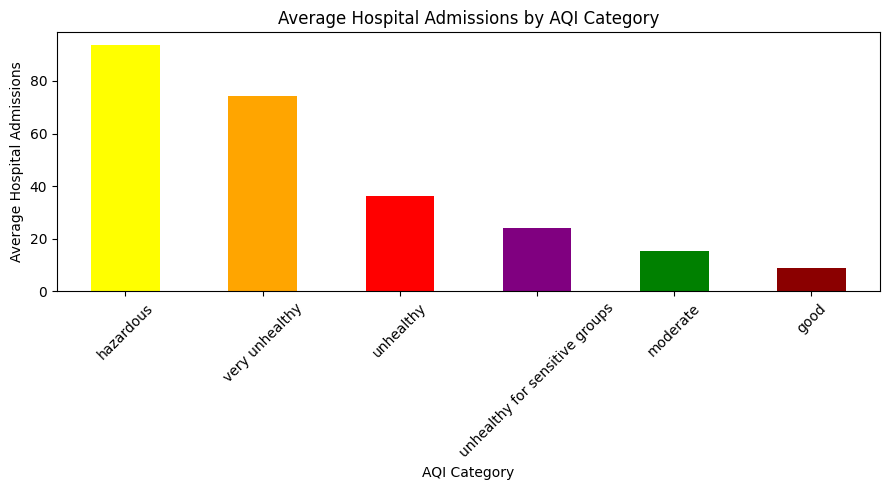

In [90]:
result = merged_df.groupby('aqi_category', observed=True)['hospital_admissions_respiratory'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(9,5),color=colors)
plt.title('Average Hospital Admissions by AQI Category')
plt.xlabel('AQI Category')
plt.ylabel('Average Hospital Admissions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average hospital admissions increase from 8.75 in Good conditions to 93.78 in Hazardous conditions.


---


 Hospitals may face considerably more respiratory admissions during severe pollution conditions and should plan resources accordingly.

### 19. What is the average PM2.5 level in each city?

city
delhi        123.390602
mumbai        78.522536
hyderabad     66.979699
bengaluru     50.072765
Name: pm25, dtype: float64


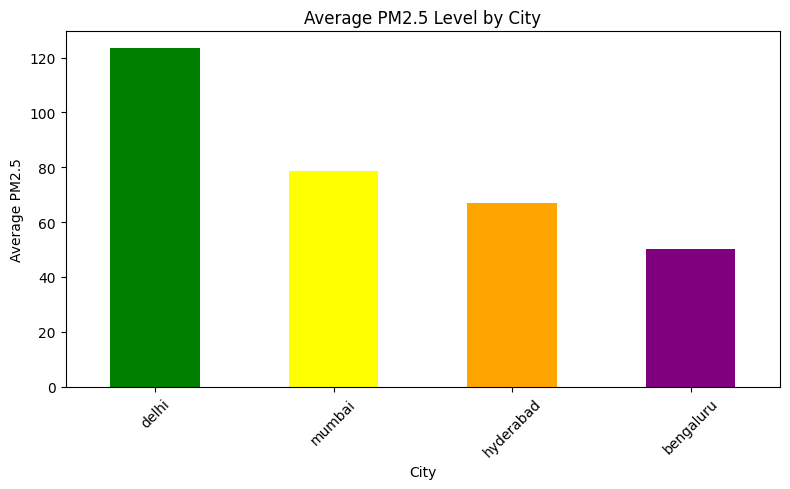

In [91]:
result = merged_df.groupby('city')['pm25'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(8,5),color=scolors)
plt.title('Average PM2.5 Level by City')
plt.xlabel('City')
plt.ylabel('Average PM2.5')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delhi has the highest average PM2.5 at 123.39, while Bengaluru has the lowest at 50.07.


---


 Delhi should receive greater attention toward reducing particulate pollution.

### 20. What is the average PM10 level in each city?

city
delhi        213.267153
mumbai       133.893887
hyderabad    113.431752
bengaluru     83.797810
Name: pm10, dtype: float64


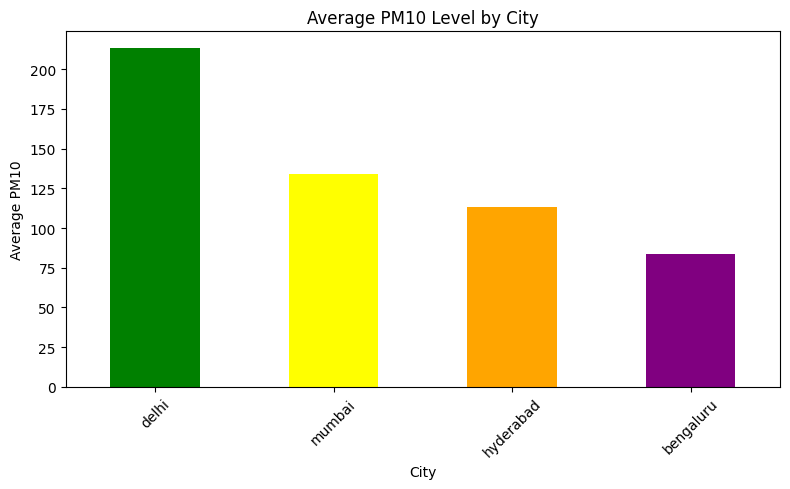

In [92]:
result = merged_df.groupby('city')['pm10'].mean().sort_values(ascending=False)
print(result)

result.plot(kind='bar', figsize=(8,5),color=scolors)
plt.title('Average PM10 Level by City')
plt.xlabel('City')
plt.ylabel('Average PM10')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delhi has the highest average PM10 at 213.27, while Bengaluru has the lowest at 83.80.


---


PM10 control can be given greater priority in cities where average levels are higher.

### 21. Do respiratory ED visits increase when PM2.5 increases?

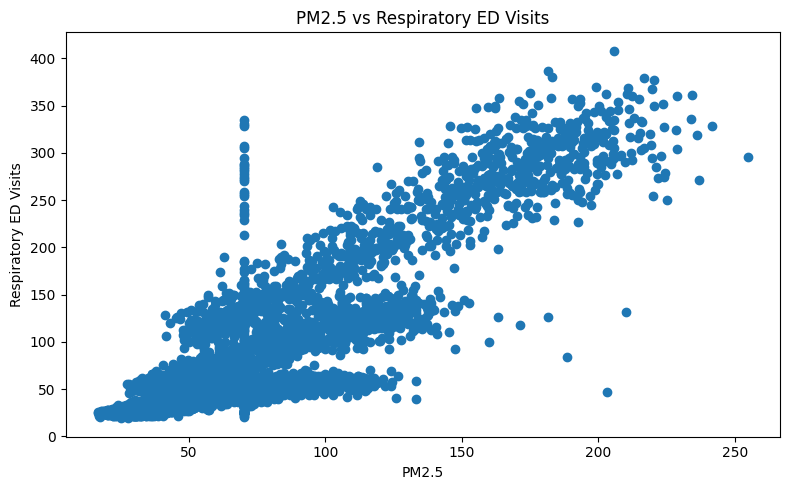

Correlation: 0.8538059437335486


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(merged_df['pm25'], merged_df['ed_visits_respiratory'])
plt.title('PM2.5 vs Respiratory ED Visits')
plt.xlabel('PM2.5')
plt.ylabel('Respiratory ED Visits')
plt.tight_layout()
plt.show()

print("Correlation:", merged_df['pm25'].corr(merged_df['ed_visits_respiratory']))

The correlation is 0.854, showing a strong positive relationship.


---


 Higher PM2.5 levels are associated with higher respiratory ED visits in this dataset, so reducing particulate exposure could be an important area for action.

### 22. Do respiratory hospital admissions increase when PM10 increases?

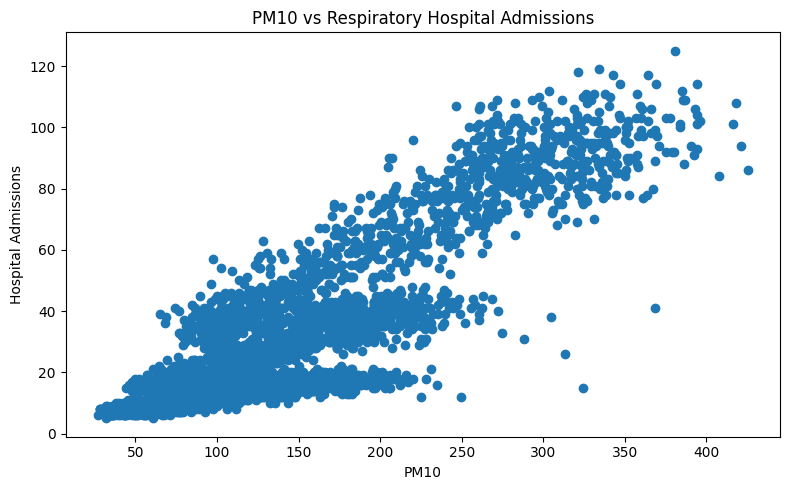

Correlation: 0.867111349974635


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(merged_df['pm10'], merged_df['hospital_admissions_respiratory'])
plt.title('PM10 vs Respiratory Hospital Admissions')
plt.xlabel('PM10')
plt.ylabel('Hospital Admissions')
plt.tight_layout()
plt.show()

print("Correlation:", merged_df['pm10'].corr(merged_df['hospital_admissions_respiratory']))

The correlation is 0.867, showing a strong positive relationship.


---


Higher PM10 levels are associated with higher respiratory hospital admissions, highlighting the importance of controlling particulate pollution.

### 23. Are respiratory ED visits higher when AQI goes above the limit?

exceedance_flag
0     58.994716
1    183.067847
Name: ed_visits_respiratory, dtype: float64


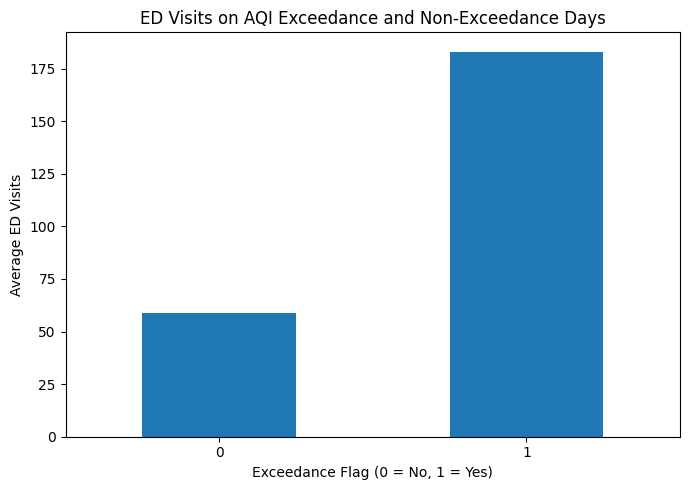

In [ ]:
result = merged_df.groupby('exceedance_flag')['ed_visits_respiratory'].mean()
print(result)

result.plot(kind='bar', figsize=(7,5))
plt.title('ED Visits on AQI Exceedance and Non-Exceedance Days')
plt.xlabel('Exceedance Flag (0 = No, 1 = Yes)')
plt.ylabel('Average ED Visits')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average ED visits are 58.99 when the AQI does not exceed the limit and 183.07 when it does exceed the limit.


---


 ED visits are much higher on exceedance days, so hospitals can use AQI alerts to prepare for increased emergency demand.

### 24. Do cities with higher population density have higher AQI?

           population_density   aqi_value
city                                     
bengaluru                4378   78.264690
delhi                   11320  200.579288
hyderabad               18480  106.732938
mumbai                  20700  126.249909


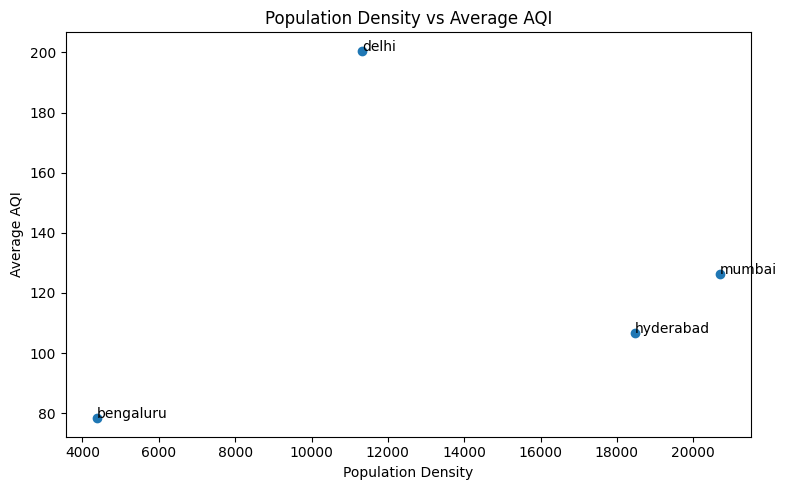

Correlation: 0.152462831945204


In [ ]:
city_data = merged_df.groupby('city').agg({
    'population_density': 'first',
    'aqi_value': 'mean'
})

print(city_data)

plt.figure(figsize=(8,5))
plt.scatter(city_data['population_density'], city_data['aqi_value'])

for city in city_data.index:
    plt.annotate(city, (city_data.loc[city, 'population_density'],
                        city_data.loc[city, 'aqi_value']))

plt.title('Population Density vs Average AQI')
plt.xlabel('Population Density')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()

print("Correlation:", city_data['population_density'].corr(city_data['aqi_value']))

The correlation is only 0.152, which is a weak relationship in this dataset.


---


Population density alone does not appear to explain AQI differences between these cities, so other pollution-related factors should also be considered.

### 25. Do AQI and respiratory ED visits follow a similar trend over time?

          aqi_value  ed_visits_respiratory
month                                     
2023-01  191.729839             135.919355
2023-02  185.300000             132.678571
2023-03  158.165323             116.717742
2023-04  125.480000              96.133333
2023-05   91.879032              76.419355
2023-06   66.515833              59.783333
2023-07   57.191935              52.846774
2023-08   66.729839              57.435484
2023-09   92.187500              72.775000
2023-10  126.539516              93.967742
2023-11  161.860833             116.941667
2023-12  185.691935             132.387097
2024-01  198.713710             140.145161
2024-02  184.237069             134.370690
2024-03  161.550806             118.830645
2024-04  143.315833             105.850000
2024-05   92.333871              76.451613
2024-06   66.752500              61.008333
2024-07   57.229839              53.782258
2024-08   69.512097              58.790323
2024-09   93.851667              74.308333
2024-10  12

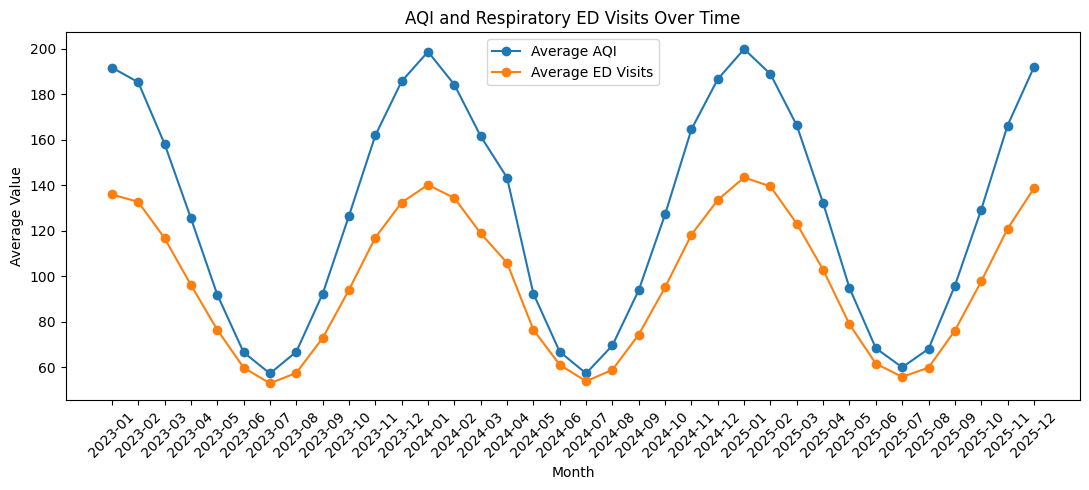

In [ ]:
monthly = merged_df.groupby('month').agg({
    'aqi_value': 'mean',
    'ed_visits_respiratory': 'mean'
})

print(monthly)

plt.figure(figsize=(11,5))
plt.plot(monthly.index, monthly['aqi_value'], marker='o', label='Average AQI')
plt.plot(monthly.index, monthly['ed_visits_respiratory'], marker='o', label='Average ED Visits')
plt.title('AQI and Respiratory ED Visits Over Time')
plt.xlabel('Month')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The monthly trends move in a very similar pattern: both are higher around January and lower around June–July.


---


 The similar seasonal pattern can help stakeholders use air-quality trends as an early indicator for periods when respiratory healthcare demand may increase.